# M06 — Dropout 0.3 (CNN 32→64→128 | LSTM 128→64 | Drop 0.3)
### SIBI Lip Reading — OFAT Model — Dataset Gabungan (18 Kelas)

**Variasi:** Regularisasi lebih longgar — melihat apakah baseline terlalu diregularisasi.

In [1]:
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [2]:
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RAW_LIPS     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
MODELS_DIR   = PROJECT_ROOT / 'models/ofat_model/M06'
RESULTS_DIR  = PROJECT_ROOT / 'results/ofat_model/M06'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

VARIANT_ID   = 'M06'
CNN_CHANNELS = [32, 64, 128]
LSTM_HIDDENS = [128, 64]
DROPOUT      = 0.3
FC_HIDDEN    = 256

BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f'Variant  : {VARIANT_ID}')
print(f'CNN ch   : {CNN_CHANNELS}')
print(f'LSTM h   : {LSTM_HIDDENS}')
print(f'Dropout  : {DROPOUT} | FC: {FC_HIDDEN}')
print(f'Classes  : {NUM_CLASSES} — {CLASSES}')
print(f'Results  → {RESULTS_DIR}')

Variant  : M06
CNN ch   : [32, 64, 128]
LSTM h   : [128, 64]
Dropout  : 0.3 | FC: 256
Classes  : 18 — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Results  → /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/results/ofat_model/M06


In [3]:
class LipDataset(Dataset):
    def __init__(self, root, classes, split):
        self.samples, self.labels = [], []
        for idx, cls in enumerate(classes):
            d = Path(root) / split / cls
            if not d.exists(): print(f'  Warning: {d} tidak ditemukan'); continue
            for f in sorted(d.glob('*.npy')):
                self.samples.append(f); self.labels.append(idx)
        print(f'  {split:5s}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq = np.load(self.samples[i]).astype(np.float32) / 255.0
        seq = torch.from_numpy(seq.transpose(3, 0, 1, 2))  # [C,T,H,W]
        return seq, torch.tensor(self.labels[i], dtype=torch.long)

print('Loading datasets...')
train_ds = LipDataset(RAW_LIPS, CLASSES, 'train')
val_ds   = LipDataset(RAW_LIPS, CLASSES, 'val')
test_ds  = LipDataset(RAW_LIPS, CLASSES, 'test')

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

x, y = next(iter(train_loader))
print(f'\nBatch shape : {x.shape}  | Label sample: {[IDX_TO_CLASS[l.item()] for l in y]}')

Loading datasets...
  train: 2520 samples
  val  : 720 samples
  test : 360 samples

Batch shape : torch.Size([8, 3, 30, 96, 96])  | Label sample: ['9', 'd', 'a', 'keliling', '2', 'f', '10', '10']


In [4]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))


class ConvLSTMModel(nn.Module):
    """
    Input : [B, 3, T, H, W] = [B, 3, 30, 96, 96]
    Output: [B, num_classes]
    cnn_channels : list channel CNN backbone
    lstm_hiddens : list hidden ConvLSTM (bisa 2 atau 3 layer)
    """
    def __init__(self, num_classes, cnn_channels, lstm_hiddens, dropout=0.5, fc_hidden=256):
        super().__init__()

        # CNN backbone
        def cblock(ic, oc):
            return nn.Sequential(nn.Conv2d(ic, oc, 3, padding=1),
                                 nn.BatchNorm2d(oc), nn.ReLU(), nn.MaxPool2d(2))
        layers, prev = [], 3
        for ch in cnn_channels:
            layers.append(cblock(prev, ch)); prev = ch
        self.cnn = nn.Sequential(*layers)

        # ConvLSTM layers
        self.lstm_cells = nn.ModuleList()
        in_ch = prev
        for h_ch in lstm_hiddens:
            self.lstm_cells.append(ConvLSTMCell(in_ch, h_ch))
            in_ch = h_ch

        self.head = nn.Sequential(
            nn.Linear(lstm_hiddens[-1], fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes)
        )

    def forward(self, x):
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)
        states = [cell.init_hidden(B, h, w, x.device) for cell in self.lstm_cells]
        for t in range(T):
            inp = x[:, t]
            for li, cell in enumerate(self.lstm_cells):
                states[li] = cell(inp, states[li])
                inp = states[li][0]
        out = states[-1][0].mean(dim=[-2, -1])  # GAP
        return self.head(out)


model = ConvLSTMModel(NUM_CLASSES, CNN_CHANNELS, LSTM_HIDDENS, DROPOUT, FC_HIDDEN).to(device)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6
print(f'Variant       : {VARIANT_ID}')
print(f'Total params  : {total_params:,}')
print(f'Model size    : {model_size_mb:.2f} MB')

Variant       : M06
Total params  : 1,737,746
Model size    : 6.95 MB


In [5]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, leave=False, desc='Train' if train else 'Eval '):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            preds_all.extend(out.argmax(1).cpu().tolist())
            labels_all.extend(y.cpu().tolist())
    return total_loss / len(loader.dataset), 100 * accuracy_score(labels_all, preds_all), preds_all, labels_all

def per_class_str(labels, preds):
    res = []
    for i, cls in enumerate(CLASSES):
        tot = sum(l == i for l in labels)
        if tot == 0: continue
        acc = round(100 * sum(p == i for p, l in zip(preds, labels) if l == i) / tot)
        res.append(f'{cls}:{acc}%')
    return '  '.join(res)

history   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[], 'epoch_time':[]}
best_val  = 0.0; best_ep = 0
best_path = MODELS_DIR / f'{VARIANT_ID}_best.pth'
t0_total  = time.time()

for ep in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, _, _       = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_p, va_l = run_epoch(val_loader,   train=False)
    scheduler.step(va_acc)
    cur_lr = optimizer.param_groups[0]['lr']
    ep_t   = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(ep_t)

    mark = ''
    if va_acc > best_val:
        best_val = va_acc; best_ep = ep
        torch.save({'model_state': model.state_dict(), 'epoch': ep,
                    'val_acc': va_acc, 'variant': VARIANT_ID}, best_path)
        mark = '  <-- best'

    print(f'{ep:4d}  loss={tr_loss:.4f} tr={tr_acc:.2f}%  val={va_acc:.2f}%  lr={cur_lr:.2e}  {ep_t:.0f}s{mark}')
    if ep % 5 == 0 or mark:
        print(f'       per-class: {per_class_str(va_l, va_p)}')

total_time = time.time() - t0_total
print(f'\nTraining selesai! Best val={best_val:.2f}% di epoch {best_ep} | Total={total_time/60:.1f} menit')

Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

   1  loss=2.6004 tr=13.49%  val=17.36%  lr=1.00e-03  58s  <-- best
       per-class: 1:0%  2:0%  3:8%  8:12%  9:30%  10:18%  a:2%  b:60%  c:32%  d:10%  e:0%  f:0%  buku:0%  dia:0%  saya:5%  keliling:82%  kelompok:52%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

  99  loss=0.0001 tr=100.00%  val=85.00%  lr=9.77e-07  59s


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval :   0%|          | 0/90 [00:00<?, ?it/s]

 100  loss=0.0002 tr=100.00%  val=85.14%  lr=9.77e-07  59s
       per-class: 1:95%  2:90%  3:80%  8:88%  9:88%  10:100%  a:100%  b:98%  c:80%  d:75%  e:78%  f:88%  buku:98%  dia:65%  saya:85%  keliling:72%  kelompok:75%  sekarang:80%

Training selesai! Best val=85.97% di epoch 93 | Total=98.0 menit


In [6]:
# Load best checkpoint → evaluasi test set
ckpt = torch.load(best_path, weights_only=False)
model.load_state_dict(ckpt['model_state'])
te_loss, te_acc, te_p, te_l = run_epoch(test_loader, train=False)

report    = classification_report(te_l, te_p, target_names=CLASSES, output_dict=True)
f1_macro  = report['macro avg']['f1-score'] * 100
f1_weight = report['weighted avg']['f1-score'] * 100
prec_w    = report['weighted avg']['precision'] * 100
rec_w     = report['weighted avg']['recall'] * 100

class_accs = []
for i in range(NUM_CLASSES):
    tot = sum(l == i for l in te_l)
    class_accs.append(100 * sum(p == i for p, l in zip(te_p, te_l) if l == i) / tot if tot else 0)

print(f'=== Hasil Test {VARIANT_ID} ===')
print(f'Test Accuracy  : {te_acc:.2f}%')
print(f'F1 Weighted    : {f1_weight:.2f}%')
print(f'F1 Macro       : {f1_macro:.2f}%')
print(f'Precision (w)  : {prec_w:.2f}%')
print(f'Recall (w)     : {rec_w:.2f}%')
print(f'Best Epoch     : {best_ep}/{NUM_EPOCHS}')
print(f'Best Val Acc   : {best_val:.2f}%')
print('\nPer-class accuracy:')
for cls, acc in zip(CLASSES, class_accs):
    flag = '✓' if acc >= 80 else ('△' if acc >= 50 else '✗')
    print(f'  {flag} {cls:12s}: {acc:.1f}%')

Eval :   0%|          | 0/45 [00:00<?, ?it/s]

=== Hasil Test M06 ===
Test Accuracy  : 84.72%
F1 Weighted    : 84.75%
F1 Macro       : 84.75%
Precision (w)  : 85.16%
Recall (w)     : 84.72%
Best Epoch     : 93/100
Best Val Acc   : 85.97%

Per-class accuracy:
  ✓ 1           : 90.0%
  ✓ 2           : 90.0%
  ✓ 3           : 85.0%
  ✓ 8           : 100.0%
  ✓ 9           : 90.0%
  ✓ 10          : 100.0%
  ✓ a           : 100.0%
  ✓ b           : 100.0%
  △ c           : 70.0%
  △ d           : 60.0%
  ✓ e           : 80.0%
  ✓ f           : 95.0%
  ✓ buku        : 85.0%
  ✓ dia         : 80.0%
  ✓ saya        : 80.0%
  △ keliling    : 75.0%
  △ kelompok    : 70.0%
  △ sekarang    : 75.0%


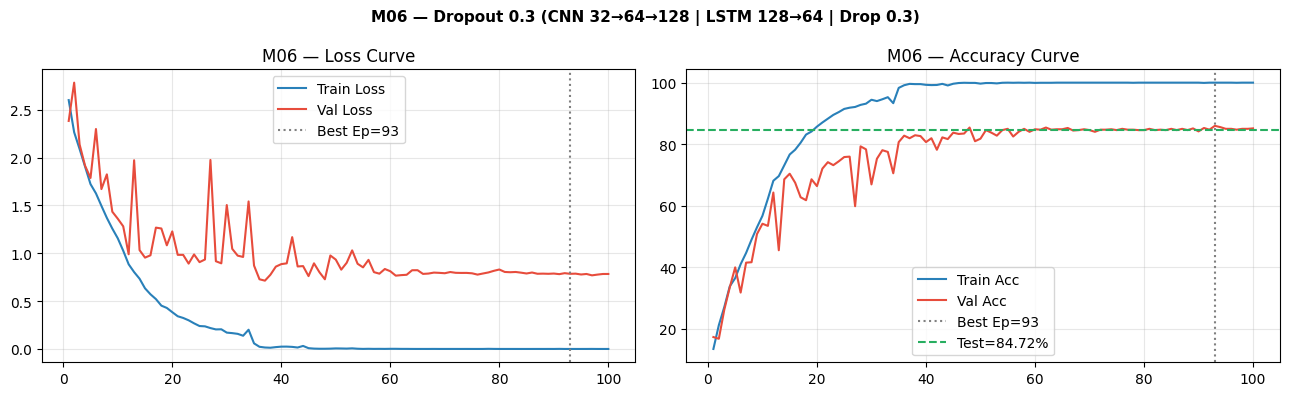

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eps = range(1, len(history['train_acc']) + 1)

axes[0].plot(eps, history['train_loss'], label='Train Loss', color='#2980B9')
axes[0].plot(eps, history['val_loss'],   label='Val Loss',   color='#E74C3C')
axes[0].axvline(best_ep, color='gray', linestyle=':', label=f'Best Ep={best_ep}')
axes[0].set_title(f'{VARIANT_ID} — Loss Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, history['train_acc'], label='Train Acc', color='#2980B9')
axes[1].plot(eps, history['val_acc'],   label='Val Acc',   color='#E74C3C')
axes[1].axvline(best_ep, color='gray', linestyle=':', label=f'Best Ep={best_ep}')
axes[1].axhline(te_acc, color='#27AE60', linestyle='--', label=f'Test={te_acc:.2f}%')
axes[1].set_title(f'{VARIANT_ID} — Accuracy Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    'M06 — Dropout 0.3 (CNN 32→64→128 | LSTM 128→64 | Drop 0.3)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

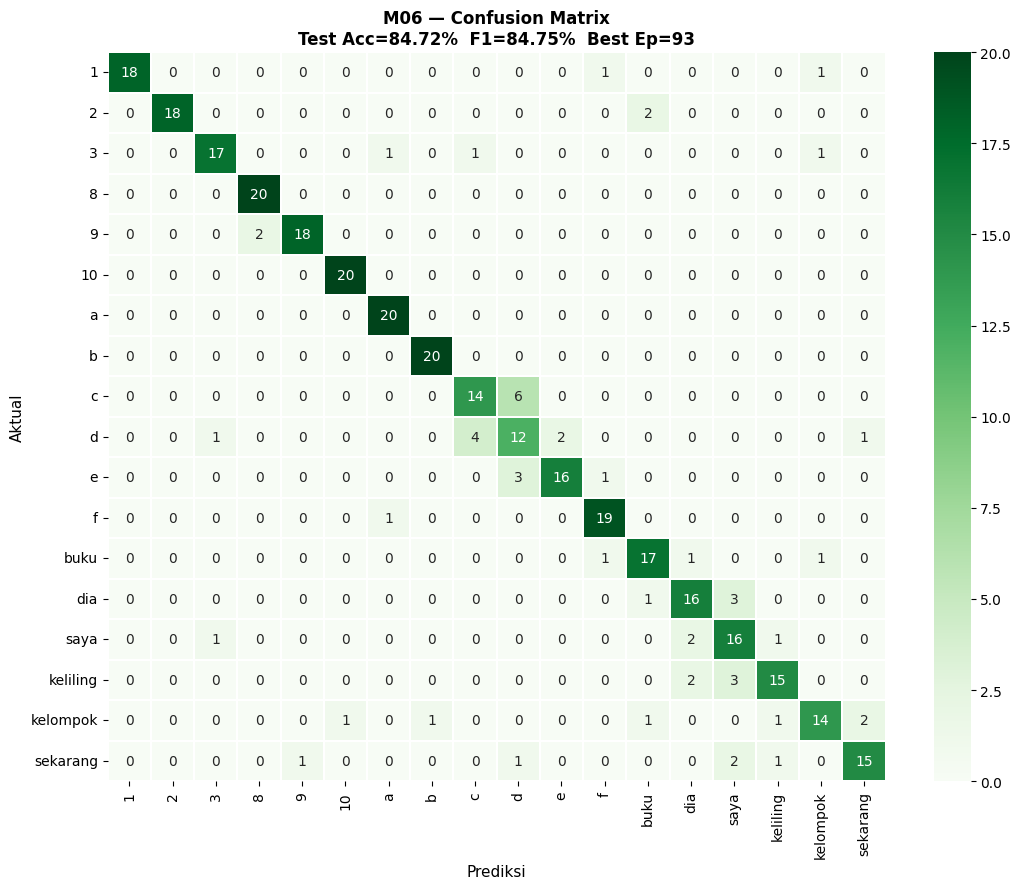

In [8]:
cm  = confusion_matrix(te_l, te_p)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, linewidths=0.3)
ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual', fontsize=11)
ax.set_title(
    'M06 — Confusion Matrix\n'
    f'Test Acc={te_acc:.2f}%  F1={f1_weight:.2f}%  Best Ep={best_ep}',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

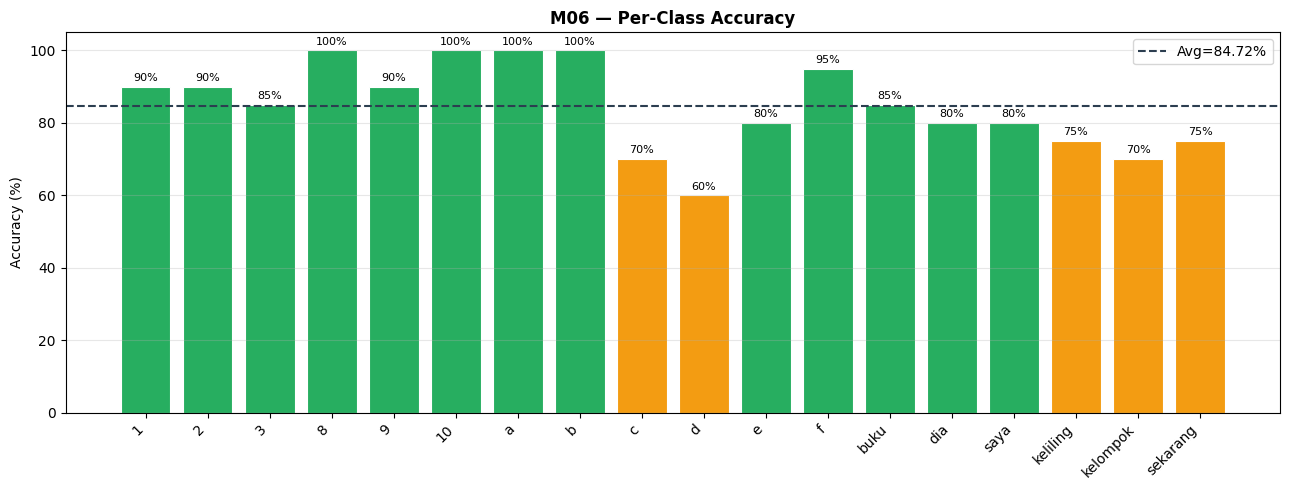

In [9]:
x = np.arange(NUM_CLASSES)
colors = ['#27AE60' if a >= 80 else ('#F39C12' if a >= 50 else '#E74C3C') for a in class_accs]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(x, class_accs, color=colors, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(te_acc, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'Avg={te_acc:.2f}%')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title(
    'M06 — Per-Class Accuracy',
    fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
summary = {
    'variant_id'  : 'M06',
    'variant_name': 'M06 — Dropout 0.3 (CNN 32→64→128 | LSTM 128→64 | Drop 0.3)',
    'config': {
        'cnn_channels': [32, 64, 128],
        'lstm_hiddens': [128, 64],
        'dropout'     : 0.3,
        'fc_hidden'   : 256,
    },
    'training': {
        'total_params': total_params, 'trainable_params': trainable_params,
        'model_size_mb': round(model_size_mb, 2),
        'best_epoch': best_ep, 'best_val_acc': round(best_val, 4),
        'batch_size': BATCH_SIZE, 'lr': LR, 'weight_decay': WEIGHT_DECAY,
        'total_time_min': round(total_time / 60, 2),
        'avg_epoch_sec' : round(sum(history['epoch_time']) / len(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss': round(te_loss, 4), 'accuracy': round(te_acc, 4),
        'f1_macro': round(f1_macro, 4), 'f1_weighted': round(f1_weight, 4),
        'precision_weighted': round(prec_w, 4), 'recall_weighted': round(rec_w, 4),
        'per_class_acc': {CLASSES[i]: round(class_accs[i], 2) for i in range(NUM_CLASSES)}
    }
}
with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

pd.DataFrame({
    'epoch': range(1, len(history['train_loss'])+1),
    'train_loss': history['train_loss'], 'train_acc': history['train_acc'],
    'val_loss'  : history['val_loss'],   'val_acc'  : history['val_acc'],
    'lr': history['lr'], 'epoch_time': history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

pd.DataFrame(
    [{'class': cls, **{k: round(report[cls][k]*100, 2) for k in ['precision','recall','f1-score']},
      'support': int(report[cls]['support'])} for cls in CLASSES]
).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print(f'=== {VARIANT_ID} — Semua Hasil Tersimpan ===')
for fname in ['summary.json','training_history.csv','classification_report.csv',
              'training_curves.png','confusion_matrix.png','per_class_accuracy.png']:
    p = RESULTS_DIR / fname
    print(f'  [{"✓" if p.exists() else "✗"}] {fname}')
print(f'\nTest Accuracy : {te_acc:.2f}%')
print(f'F1 Weighted   : {f1_weight:.2f}%')
print(f'Best Epoch    : {best_ep}/{NUM_EPOCHS}')

=== M06 — Semua Hasil Tersimpan ===
  [✓] summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png

Test Accuracy : 84.72%
F1 Weighted   : 84.75%
Best Epoch    : 93/100
